In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import copy

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Menggunakan perangkat: {device}")

path_embeddings = 'distilbert_sequence_embeddings.npy'
path_labels = 'label_sentimen.npy'

X_features = np.load(path_embeddings)
# UBAH BARIS DI BAWAH INI: Tambahkan allow_pickle=True
y_labels = np.load(path_labels, allow_pickle=True)

if len(X_features) != len(y_labels):
    print("Jumlah baris pada matriks embedding dan label tidak sama!")
    print(f"Jumlah vektor: {len(X_features)}, Jumlah label: {len(y_labels)}")
else:
    print(f"Data berhasil dimuat. Total data: {len(X_features)}")

Menggunakan perangkat: cuda
Data berhasil dimuat. Total data: 8943


In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)
num_classes = len(le.classes_)

print(f"Mapping Kelas: {dict(zip(le.classes_, le.transform(le.classes_)))}")

X_seq = X_features

Mapping Kelas: {'negatif': np.int64(0), 'netral': np.int64(1), 'positif': np.int64(2)}


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, dropout_rate=0.5):
        super(BiLSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(input_size=input_dim,
                            hidden_size=hidden_dim,
                            num_layers=1,
                            bidirectional=True,
                            batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        lstm_out, (hn, cn) = self.lstm(x)

        hidden_concat = torch.cat((hn[0, :, :], hn[1, :, :]), dim=1)

        dropped_out = self.dropout(hidden_concat)
        out = self.fc(dropped_out)
        return out

model = BiLSTMClassifier(input_dim=768, hidden_dim=128, num_classes=num_classes).to(device)

In [6]:
bobot_manual = [1.0, 1.6, 1.3] 

print(f"Bobot kelas manual yang diterapkan (Negatif, Netral, Positif): {bobot_manual}")
class_weights_tensor = torch.tensor(bobot_manual, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

Bobot kelas manual yang diterapkan (Negatif, Netral, Positif): [1.0, 1.6, 1.3]


In [7]:
epochs = 10
patience = 3
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None

train_losses, test_losses = [], []
train_accs, test_accs = [], []

print("\nMemulai proses pelatihan model BiLSTM dengan Early Stopping...\n")
for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    model.eval()
    test_loss, correct_test, total_test = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_loss = test_loss / len(test_loader)
    test_acc = correct_test / total_test

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {test_loss:.4f}, Val Acc: {test_acc:.4f}")

    if test_loss < best_val_loss:
        best_val_loss = test_loss
        epochs_no_improve = 0
        best_model_state = copy.deepcopy(model.state_dict())
    else:
        epochs_no_improve += 1
        print(f"Tidak ada peningkatan performa selama {epochs_no_improve} epoch.")
        if epochs_no_improve >= patience:
            print(f"\n[INFO] Early stopping terpicu! Menghentikan pelatihan di epoch {epoch+1}.")
            break


Memulai proses pelatihan model BiLSTM dengan Early Stopping...

Epoch [1/10] | Train Loss: 0.8514, Train Acc: 0.6835 | Val Loss: 0.6695, Val Acc: 0.7731
Epoch [2/10] | Train Loss: 0.6280, Train Acc: 0.7791 | Val Loss: 0.5723, Val Acc: 0.7870
Epoch [3/10] | Train Loss: 0.5549, Train Acc: 0.7952 | Val Loss: 0.5508, Val Acc: 0.7887
Epoch [4/10] | Train Loss: 0.5175, Train Acc: 0.8089 | Val Loss: 0.5379, Val Acc: 0.7949
Epoch [5/10] | Train Loss: 0.4899, Train Acc: 0.8207 | Val Loss: 0.5397, Val Acc: 0.7870
Tidak ada peningkatan performa selama 1 epoch.
Epoch [6/10] | Train Loss: 0.4524, Train Acc: 0.8377 | Val Loss: 0.5263, Val Acc: 0.7988
Epoch [7/10] | Train Loss: 0.4265, Train Acc: 0.8467 | Val Loss: 0.5304, Val Acc: 0.7921
Tidak ada peningkatan performa selama 1 epoch.
Epoch [8/10] | Train Loss: 0.3959, Train Acc: 0.8560 | Val Loss: 0.5512, Val Acc: 0.8027
Tidak ada peningkatan performa selama 2 epoch.
Epoch [9/10] | Train Loss: 0.3702, Train Acc: 0.8669 | Val Loss: 0.5393, Val Acc: 

In [8]:
model.load_state_dict(best_model_state)
model.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

print("\nLAPORAN KLASIFIKASI")
print(classification_report(all_targets, all_preds, target_names=le.classes_))


LAPORAN KLASIFIKASI
              precision    recall  f1-score   support

     negatif       0.87      0.88      0.87      1071
      netral       0.62      0.61      0.62       297
     positif       0.74      0.72      0.73       421

    accuracy                           0.80      1789
   macro avg       0.74      0.74      0.74      1789
weighted avg       0.80      0.80      0.80      1789



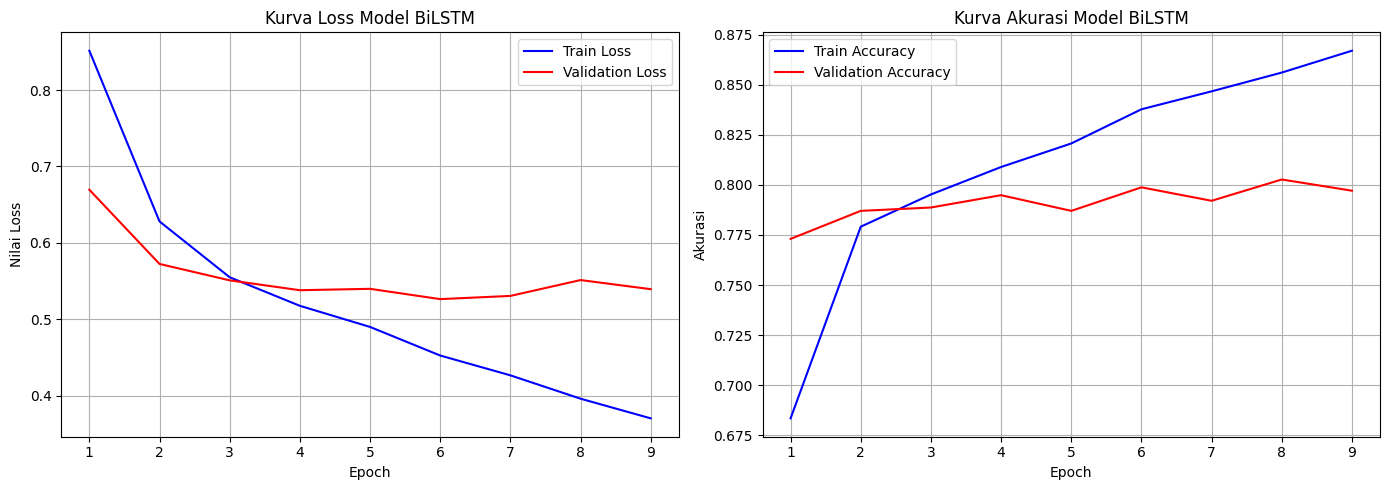

In [9]:
# 8. VISUALISASI
plt.figure(figsize=(14, 5))
actual_epochs = len(train_losses)

plt.subplot(1, 2, 1)
plt.plot(range(1, actual_epochs+1), train_losses, label='Train Loss', color='blue')
plt.plot(range(1, actual_epochs+1), test_losses, label='Validation Loss', color='red')
plt.title('Kurva Loss Model BiLSTM')
plt.xlabel('Epoch')
plt.ylabel('Nilai Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, actual_epochs+1), train_accs, label='Train Accuracy', color='blue')
plt.plot(range(1, actual_epochs+1), test_accs, label='Validation Accuracy', color='red')
plt.title('Kurva Akurasi Model BiLSTM')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

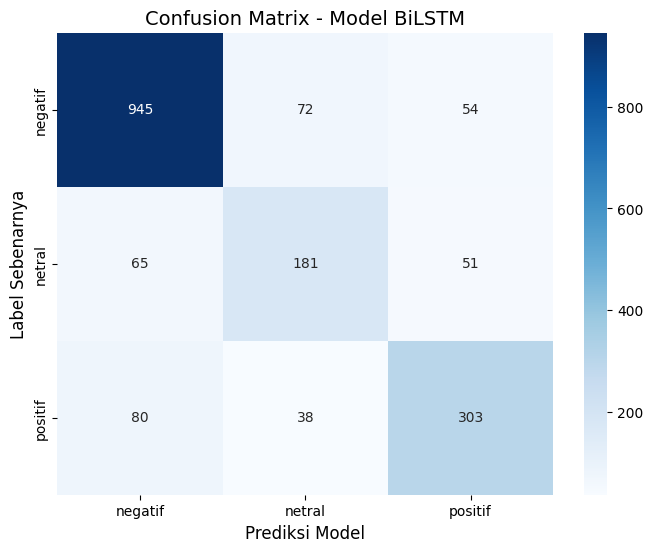

In [ ]:
# Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)
class_names = le.classes_ 

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prediksi Model', fontsize=12)
plt.ylabel('Label Sebenarnya', fontsize=12)
plt.title('Confusion Matrix - Model BiLSTM', fontsize=14)
plt.show()

In [11]:
path_simpan_model = 'model_bilstm_sentimen_ikn.pth'
torch.save(model.state_dict(), path_simpan_model)
print(f"Model berhasil disimpan di \n{path_simpan_model}")

Model berhasil disimpan di 
model_bilstm_sentimen_ikn.pth
